In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt

In [2]:
df=pd.read_csv("C:/Users/surek/output/ecommerce_return_predictions.csv")

In [3]:
df

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,...,Payment_Method,Shipping_Method,Discount_Applied,return_flag,Total_Price,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,predicted_return_prob
0,ORD00000000,PROD00000000,USER00000000,8/5/2023,8/26/2024,Clothing,411.59,3,Changed mind,Returned,...,Debit Card,Next-Day,45.27,1,1234.77,2023,8,5,Saturday,0.594522
1,ORD00000001,PROD00000001,USER00000001,10/9/2023,11/9/2023,Books,288.88,3,Wrong item,Returned,...,Credit Card,Express,47.79,1,866.64,2023,10,9,Monday,0.684405
2,ORD00000002,PROD00000002,USER00000002,5/6/2023,NaN,Toys,390.03,5,NaN,Not Returned,...,Debit Card,Next-Day,26.64,0,1950.15,2023,5,6,Saturday,0.388571
3,ORD00000003,PROD00000003,USER00000003,8/29/2024,NaN,Toys,401.09,3,NaN,Not Returned,...,PayPal,Next-Day,15.37,0,1203.27,2024,8,29,Thursday,0.296047
4,ORD00000004,PROD00000004,USER00000004,1/16/2023,NaN,Books,110.09,4,NaN,Not Returned,...,Gift Card,Standard,16.37,0,440.36,2023,1,16,Monday,0.514714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ORD00009995,PROD00009995,USER00009995,10/20/2023,NaN,Home,142.50,4,NaN,Not Returned,...,PayPal,Standard,34.27,0,570.00,2023,10,20,Friday,0.459364
9996,ORD00009996,PROD00009996,USER00009996,2/25/2023,NaN,Electronics,484.63,3,NaN,Not Returned,...,Debit Card,Express,25.44,0,1453.89,2023,2,25,Saturday,0.327726
9997,ORD00009997,PROD00009997,USER00009997,5/10/2024,NaN,Toys,386.57,5,NaN,Not Returned,...,Credit Card,Next-Day,12.67,0,1932.85,2024,5,10,Friday,0.636028
9998,ORD00009998,PROD00009998,USER00009998,2/13/2024,NaN,Toys,129.22,1,NaN,Not Returned,...,Gift Card,Express,49.97,0,129.22,2024,2,13,Tuesday,0.378030


In [6]:
df.columns

Index(['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Return_Date',
       'Product_Category', 'Product_Price', 'Order_Quantity', 'Return_Reason',
       'Return_Status', 'Days_to_Return', 'User_Age', 'User_Gender',
       'User_Location', 'Payment_Method', 'Shipping_Method',
       'Discount_Applied', 'return_flag', 'Total_Price', 'Order_Year',
       'Order_Month', 'Order_Day', 'Order_DayOfWeek', 'predicted_return_prob'],
      dtype='object')

In [7]:
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               10000 non-null  object 
 1   Product_ID             10000 non-null  object 
 2   User_ID                10000 non-null  object 
 3   Order_Date             10000 non-null  object 
 4   Return_Date            5052 non-null   object 
 5   Product_Category       10000 non-null  object 
 6   Product_Price          10000 non-null  float64
 7   Order_Quantity         10000 non-null  int64  
 8   Return_Reason          5052 non-null   object 
 9   Return_Status          10000 non-null  object 
 10  Days_to_Return         5052 non-null   float64
 11  User_Age               10000 non-null  int64  
 12  User_Gender            10000 non-null  object 
 13  User_Location          10000 non-null  object 
 14  Payment_Method         10000 non-null  object 
 15  Shi

Order_ID                    0
Product_ID                  0
User_ID                     0
Order_Date                  0
Return_Date              4948
Product_Category            0
Product_Price               0
Order_Quantity              0
Return_Reason            4948
Return_Status               0
Days_to_Return           4948
User_Age                    0
User_Gender                 0
User_Location               0
Payment_Method              0
Shipping_Method             0
Discount_Applied            0
return_flag                 0
Total_Price                 0
Order_Year                  0
Order_Month                 0
Order_Day                   0
Order_DayOfWeek             0
predicted_return_prob       0
dtype: int64

In [10]:
df['Order_Date'].head(20)

0    2023-08-05
1    2023-10-09
2    2023-05-06
3    2024-08-29
4    2023-01-16
5    2024-02-14
6    2023-05-29
7    2023-02-09
8    2024-12-25
9    2023-03-10
10   2024-05-26
11   2024-02-08
12   2024-06-07
13   2023-07-22
14   2024-09-01
15   2024-10-02
16   2024-05-09
17   2023-02-03
18   2024-10-07
19   2024-07-06
Name: Order_Date, dtype: datetime64[ns]

In [11]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')


In [12]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y', errors='coerce')


In [13]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m/%d/%Y', errors='coerce')


In [14]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%y', errors='coerce')


In [15]:
df['Order_Date'].info()
df['Order_Date'].head()


<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Order_Date
Non-Null Count  Dtype         
--------------  -----         
10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 78.3 KB


0   2023-08-05
1   2023-10-09
2   2023-05-06
3   2024-08-29
4   2023-01-16
Name: Order_Date, dtype: datetime64[ns]

In [16]:
df['Order_Date'].unique()[:10]


<DatetimeArray>
['2023-08-05 00:00:00', '2023-10-09 00:00:00', '2023-05-06 00:00:00',
 '2024-08-29 00:00:00', '2023-01-16 00:00:00', '2024-02-14 00:00:00',
 '2023-05-29 00:00:00', '2023-02-09 00:00:00', '2024-12-25 00:00:00',
 '2023-03-10 00:00:00']
Length: 10, dtype: datetime64[ns]

In [17]:
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day
df['Order_DayOfWeek'] = df['Order_Date'].dt.day_name()


In [18]:
df['Return_Date'] = pd.to_datetime(df['Return_Date'], errors='coerce')


In [20]:
df['Days_to_Return'] = (df['Return_Date'] - df['Order_Date']).dt.days


In [21]:
# Convert dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Return_Date'] = pd.to_datetime(df['Return_Date'], errors='coerce')

# Extract date features
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day
df['Order_DayOfWeek'] = df['Order_Date'].dt.day_name()

# Days to return
df['Days_to_Return'] = (df['Return_Date'] - df['Order_Date']).dt.days


In [22]:
df[['Order_Date', 'Return_Date']].head(20)


,Order_Date,Return_Date
0,2023-08-05,2024-08-26
1,2023-10-09,2023-11-09
2,2023-05-06,NaT
3,2024-08-29,NaT
4,2023-01-16,NaT
5,2024-02-14,2024-09-22
6,2023-05-29,2023-08-03
7,2023-02-09,2024-08-01
8,2024-12-25,2024-09-25
9,2023-03-10,2024-01-21


In [23]:
df['Return_Date'].isna().sum()


np.int64(4948)

In [24]:
df[df['Return_Date'].isna()].head(20)


,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,...,Shipping_Method,Discount_Applied,return_flag,Total_Price,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,predicted_return_prob,Revenue
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaT,Toys,390.03,5,NaN,Not Returned,...,Next-Day,26.64,0,1950.15,2023,5,6,Saturday,0.388571,9750.75
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaT,Toys,401.09,3,NaN,Not Returned,...,Next-Day,15.37,0,1203.27,2024,8,29,Thursday,0.296047,3609.81
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaT,Books,110.09,4,NaN,Not Returned,...,Standard,16.37,0,440.36,2023,1,16,Monday,0.514714,1761.44
10,ORD00000010,PROD00000010,USER00000010,2024-05-26,NaT,Toys,119.00,2,NaN,Not Returned,...,Next-Day,8.72,0,238.00,2024,5,26,Sunday,0.308241,476.00
11,ORD00000011,PROD00000011,USER00000011,2024-02-08,NaT,Home,480.48,4,NaN,Not Returned,...,Next-Day,0.27,0,1921.92,2024,2,8,Thursday,0.272172,7687.68
12,ORD00000012,PROD00000012,USER00000012,2024-06-07,NaT,Toys,216.41,3,NaN,Not Returned,...,Standard,30.26,0,649.23,2024,6,7,Friday,0.342325,1947.69
13,ORD00000013,PROD00000013,USER00000013,2023-07-22,NaT,Electronics,198.78,2,NaN,Not Returned,...,Next-Day,36.58,0,397.56,2023,7,22,Saturday,0.320350,795.12
14,ORD00000014,PROD00000014,USER00000014,2024-09-01,NaT,Electronics,146.37,4,NaN,Not Returned,...,Next-Day,28.23,0,585.48,2024,9,1,Sunday,0.543799,2341.92
16,ORD00000016,PROD00000016,USER00000016,2024-05-09,NaT,Clothing,311.08,1,NaN,Not Returned,...,Standard,6.66,0,311.08,2024,5,9,Thursday,0.321001,311.08
20,ORD00000020,PROD00000020,USER00000020,2023-07-03,NaT,Clothing,6.14,1,NaN,Not Returned,...,Next-Day,47.47,0,6.14,2023,7,3,Monday,0.409072,6.14


In [26]:
df['Return_Date'].unique()[:15]


<DatetimeArray>
['2024-08-26 00:00:00', '2023-11-09 00:00:00',                 'NaT',
 '2024-09-22 00:00:00', '2023-08-03 00:00:00', '2024-08-01 00:00:00',
 '2024-09-25 00:00:00', '2024-01-21 00:00:00', '2023-12-04 00:00:00',
 '2023-06-03 00:00:00', '2023-03-18 00:00:00', '2024-05-01 00:00:00',
 '2023-01-06 00:00:00', '2023-09-13 00:00:00', '2024-01-24 00:00:00']
Length: 15, dtype: datetime64[ns]

In [27]:
# Days_to_Return = difference only when returned
df['Days_to_Return'] = (df['Return_Date'] - df['Order_Date']).dt.days

# Fill non-returned items with 0 (or keep as NaN – your choice)
df['Days_to_Return'] = df['Days_to_Return'].fillna(0)


In [28]:
df.loc[df['Return_Status'] == 'Not Returned', 'Days_to_Return'] = 0
df.loc[df['Return_Status'] == 'Returned', 'Days_to_Return'] = (
    df['Return_Date'] - df['Order_Date']
).dt.days


In [29]:
df['Days_to_Return'] = np.where(
    df['Return_Status'] == 'Returned',
    (df['Return_Date'] - df['Order_Date']).dt.days,
    0
)


In [33]:
import pandas as pd
import numpy as np

# Total Revenue
total_revenue = df['Total_Price'].sum()
print("Total Revenue:", total_revenue)

# AOV
aov = df['Total_Price'].mean()
print("Average Order Value:", aov)

# Unique customers
unique_customers = df['User_ID'].nunique()
print("Total Customers:", unique_customers)

# Return rate
return_rate = (df['Return_Status'] == 'Returned').mean() * 100
print("Return Rate (%):", return_rate)

# Category-wise sales
category_sales = df.groupby('Product_Category')['Total_Price'].sum()
print("\nCategory-wise Sales:\n", category_sales)

# Category-wise return %
category_return_rate = df.groupby('Product_Category')['Return_Status'].apply(lambda x: (x=="Returned").mean()*100)
print("\nCategory-wise Return Rate (%):\n", category_return_rate)

# Top customers
top_customers = df.groupby('User_ID')['Total_Price'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Customers:\n", top_customers)

# Monthly sales
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Price'].sum()
print("\nMonthly Sales:\n", monthly_sales)


Total Revenue: 7626183.5600000005
Average Order Value: 762.6183560000001
Total Customers: 10000
Return Rate (%): 50.519999999999996

Category-wise Sales:
 Product_Category
Books          1533423.95
Clothing       1524592.80
Electronics    1501047.33
Home           1563855.82
Toys           1503263.66
Name: Total_Price, dtype: float64

Category-wise Return Rate (%):
 Product_Category
Books          50.661440
Clothing       52.450000
Electronics    50.931990
Home           49.014778
Toys           49.537037
Name: Return_Status, dtype: float64

Top 10 Customers:
 User_ID
USER00001295    2498.30
USER00002534    2496.90
USER00006079    2495.15
USER00002124    2494.05
USER00008754    2493.15
USER00008434    2493.15
USER00002283    2492.85
USER00008586    2492.40
USER00008407    2492.30
USER00001349    2491.95
Name: Total_Price, dtype: float64

Monthly Sales:
 Order_Date
2023-01    326638.80
2023-02    266041.76
2023-03    322680.06
2023-04    336769.30
2023-05    324216.10
2023-06    296695.

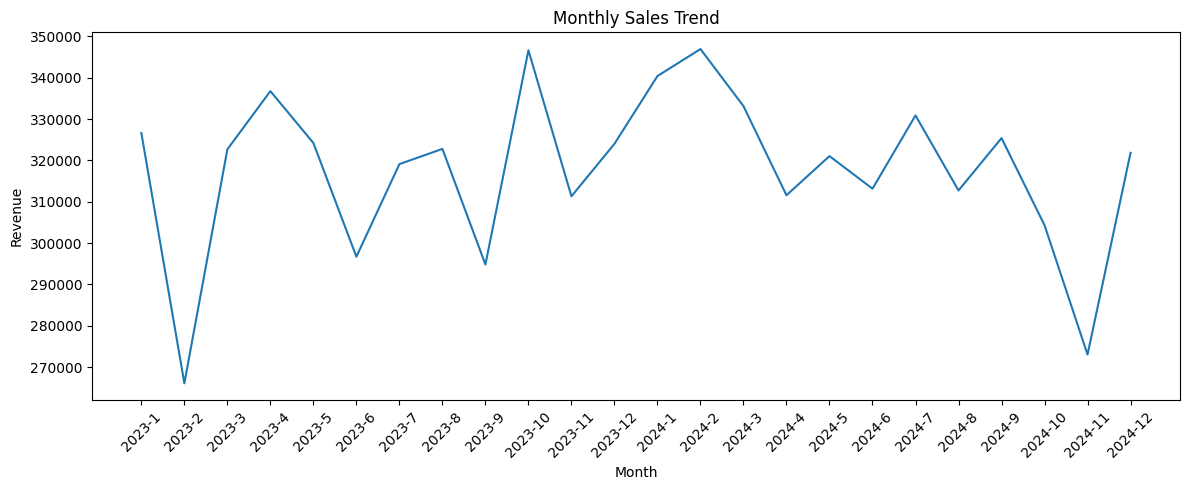

In [34]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby(['Order_Year', 'Order_Month'])['Total_Price'].sum().reset_index()
monthly_sales['Year-Month'] = monthly_sales['Order_Year'].astype(str) + "-" + monthly_sales['Order_Month'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Year-Month'], monthly_sales['Total_Price'])
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


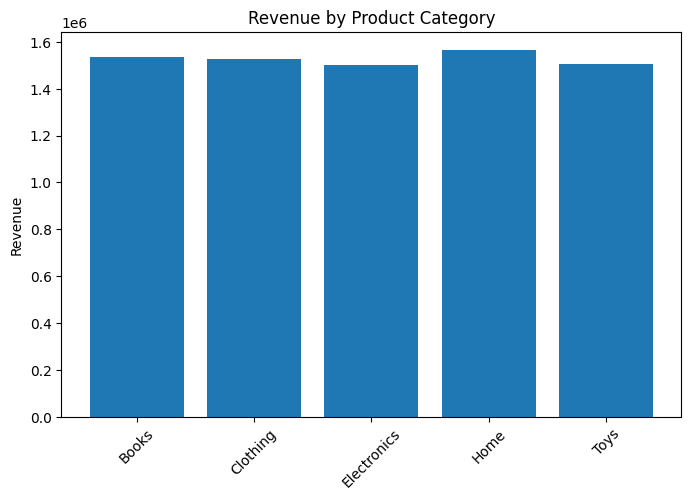

In [35]:
category_sales = df.groupby('Product_Category')['Total_Price'].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)
plt.xticks(rotation=45)
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()


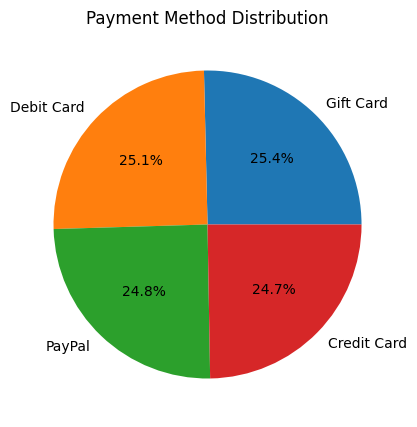

In [36]:
payment_counts = df['Payment_Method'].value_counts()

plt.figure(figsize=(7,5))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()


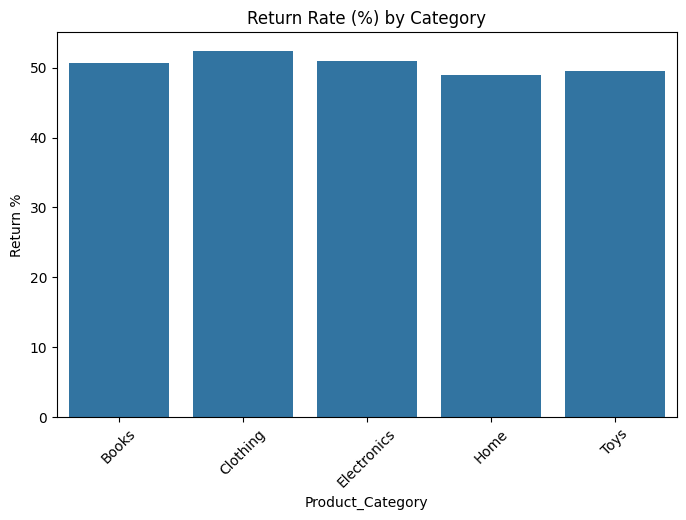

In [37]:


category_return_rate = df.groupby('Product_Category')['return_flag'].mean().reset_index()
category_return_rate['return_flag'] *= 100

plt.figure(figsize=(8,5))
sns.barplot(x='Product_Category', y='return_flag', data=category_return_rate)
plt.title("Return Rate (%) by Category")
plt.xticks(rotation=45)
plt.ylabel("Return %")
plt.show()


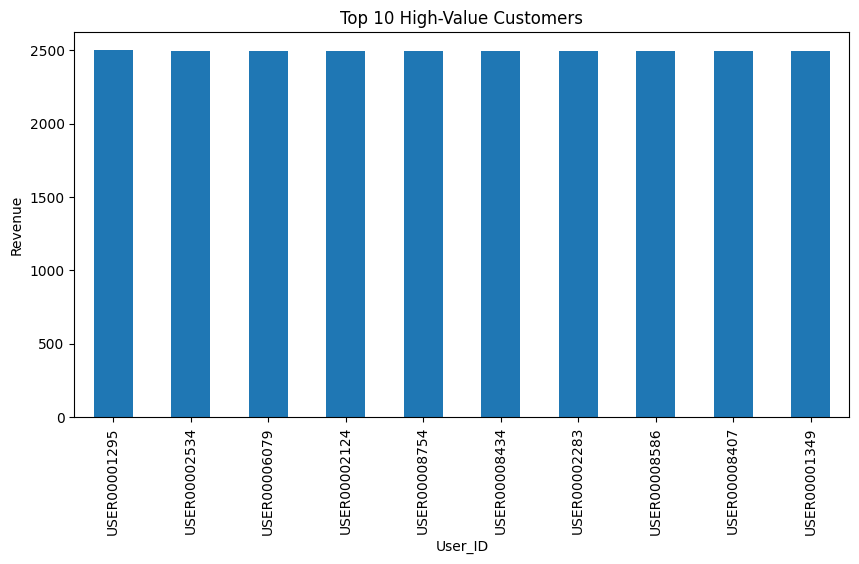

In [38]:
top_customers = df.groupby('User_ID')['Total_Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title("Top 10 High-Value Customers")
plt.ylabel("Revenue")
plt.show()


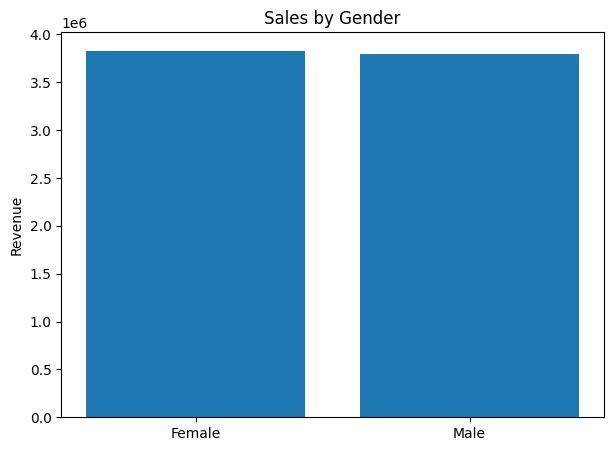

In [39]:
gender_sales = df.groupby('User_Gender')['Total_Price'].sum()

plt.figure(figsize=(7,5))
plt.bar(gender_sales.index, gender_sales.values)
plt.title("Sales by Gender")
plt.ylabel("Revenue")
plt.show()


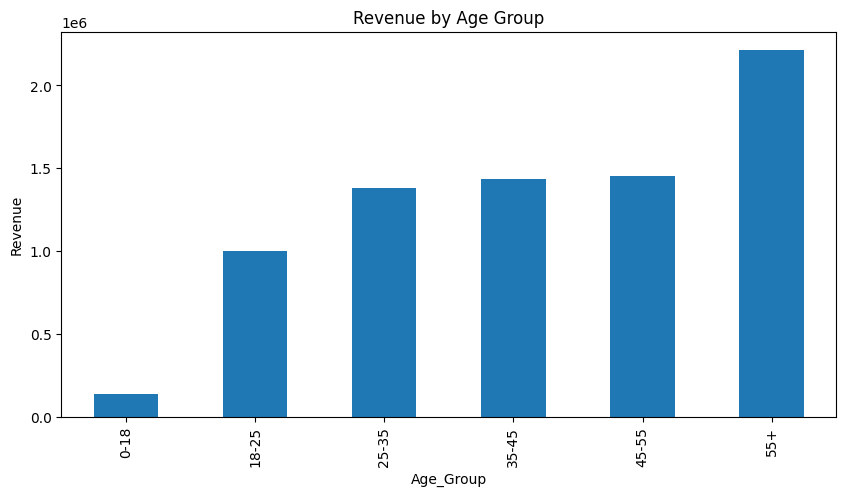

In [41]:
df['Age_Group'] = pd.cut(df['User_Age'], bins=[0,18,25,35,45,55,100],
                         labels=['0-18','18-25','25-35','35-45','45-55','55+'])

age_sales = df.groupby('Age_Group', observed=False)['Total_Price'].sum()


plt.figure(figsize=(10,5))
age_sales.plot(kind='bar')
plt.title("Revenue by Age Group")
plt.ylabel("Revenue")
plt.show()


In [43]:
features = [
    'Product_Price', 'Order_Quantity', 'Discount_Applied',
    'User_Age', 'Payment_Method', 'Shipping_Method',
    'Product_Category', 'User_Gender', 'User_Location',
    'Days_to_Return'
]

target = 'return_flag'



In [44]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()
le = LabelEncoder()

categorical_cols = ['Payment_Method', 'Shipping_Method', 'Product_Category',
                    'User_Gender', 'User_Location']

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))


In [45]:
X = df_ml[features]
y = df_ml[target]


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.48

Confusion Matrix:
 [[358 651]
 [389 602]]

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.35      0.41      1009
           1       0.48      0.61      0.54       991

    accuracy                           0.48      2000
   macro avg       0.48      0.48      0.47      2000
weighted avg       0.48      0.48      0.47      2000



In [49]:
df['predicted_return_prob'] = model.predict_proba(X)[:,1]
df[['return_flag', 'predicted_return_prob']].head()


,return_flag,predicted_return_prob
0,1,0.526917
1,1,0.553054
2,0,0.513162
3,0,0.475556
4,0,0.522122


In [50]:
importance = model.coef_[0]
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(importance)
}).sort_values(by='Importance', ascending=False)

feature_importance_lr


,Feature,Importance
4,Payment_Method,0.036550
6,Product_Category,0.022259
1,Order_Quantity,0.008986
2,Discount_Applied,0.005211
7,User_Gender,0.005162
3,User_Age,0.002512
5,Shipping_Method,0.001875
8,User_Location,0.000721
0,Product_Price,0.000137
9,Days_to_Return,0.000028


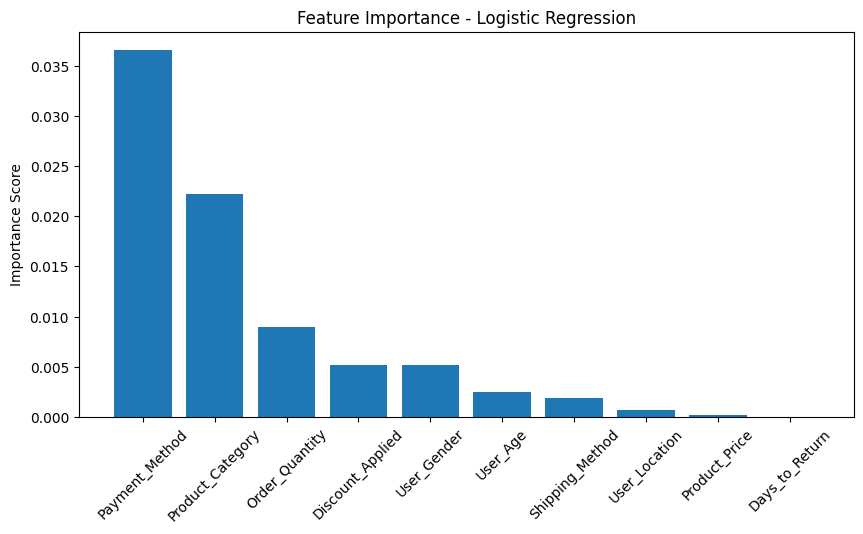

In [51]:
plt.figure(figsize=(10,5))
plt.bar(feature_importance_lr['Feature'], feature_importance_lr['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance - Logistic Regression")
plt.ylabel("Importance Score")
plt.show()


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance


,Feature,Importance
9,Days_to_Return,0.932403
2,Discount_Applied,0.015417
0,Product_Price,0.014829
8,User_Location,0.011501
3,User_Age,0.010604
1,Order_Quantity,0.003939
6,Product_Category,0.003833
4,Payment_Method,0.003395
5,Shipping_Method,0.002527
7,User_Gender,0.001552


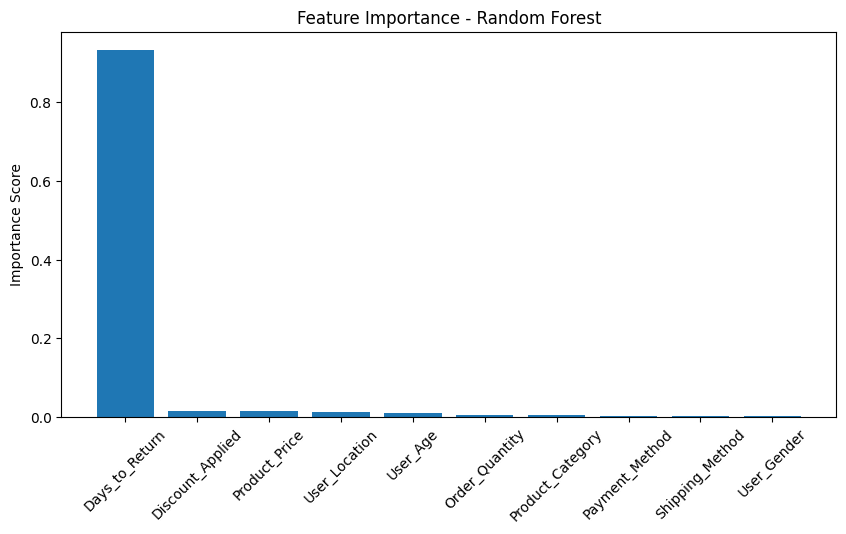

In [54]:
plt.figure(figsize=(10,5))
plt.bar(rf_importance['Feature'], rf_importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()


In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions
y_pred_lr = model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


=== Logistic Regression ===
Accuracy: 0.48
Precision: 0.48044692737430167
Recall: 0.6074672048435923
F1-score: 0.5365418894830659

Confusion Matrix:
 [[358 651]
 [389 602]]


In [56]:
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


=== Random Forest ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Confusion Matrix:
 [[1009    0]
 [   0  991]]


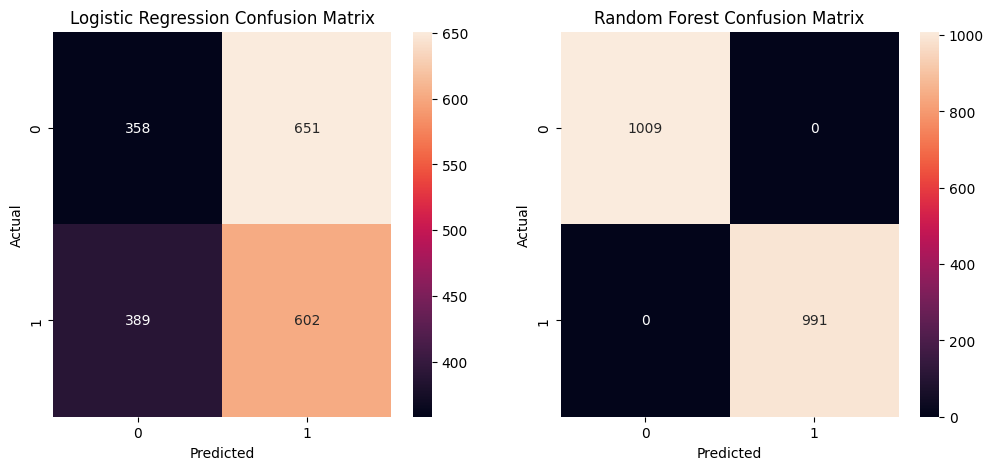

In [57]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', ax=ax[0])
ax[0].set_title("Logistic Regression Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=ax[1])
ax[1].set_title("Random Forest Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encode categorical columns
cat_cols = ['Payment_Method', 'Shipping_Method', 'Product_Category', 'User_Gender', 'User_Location']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Features & target
features = ['Product_Price', 'Order_Quantity', 'Discount_Applied',
            'User_Age', 'Payment_Method', 'Shipping_Method', 
            'Product_Category', 'User_Gender', 'User_Location', 'Days_to_Return']
X = df[features]
y = df['return_flag']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       991

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

